In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
import os

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

# random seed
np.random.seed(42)

In [3]:
print(f"Current working directory: {os.getcwd()}")

# os.chdir(Path(os.getcwd()).parent)
# print(f"New working directory: {os.getcwd()}")


Current working directory: /home/sjoon/projects/brain_connectivity_classifier


In [4]:
# Load Data
PIOP2_PATH = "data/raw/PIOP2_restingstate.csv"
PIOP1_PATH = "data/raw/PIOP1_gstroop.csv"

# Load datasets
df_rest = pd.read_csv(PIOP2_PATH)
df_task = pd.read_csv(PIOP1_PATH)

print(f"PIOP2 (Rest) shape: {df_rest.shape}")
print(f"PIOP1 (Task) shape: {df_task.shape}")
print(f"\nFirst few columns: {list(df_rest.columns[:5])}")

PIOP2 (Rest) shape: (224, 26797)
PIOP1 (Task) shape: (200, 26797)

First few columns: ['subject', 'LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2', 'LH_VisCent_ExStr_3~LH_VisCent_ExStr_1']


In [5]:
# Extract subject IDs and connection data
subject_col = df_rest.columns[0]
connection_cols = [col for col in df_rest.columns if '~' in str(col)]

print(f"Subject ID column: {subject_col}")
print(f"Number of connection columns: {len(connection_cols)}")
print(f"Sample connection columns: {connection_cols[:3]}")

# Extract connectivity matrices
X_rest = df_rest[connection_cols].values
X_task = df_task[connection_cols].values

print(f"\nX_rest shape: {X_rest.shape}")
print(f"X_task shape: {X_task.shape}")

Subject ID column: subject
Number of connection columns: 26796
Sample connection columns: ['LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2']



X_rest shape: (224, 26796)
X_task shape: (200, 26796)


In [6]:
# Subject-Level Analysis
print("SECTION 5: SUBJECT-LEVEL VARIABILITY")

# Compute subject-level statistics
print("\nComputing subject-level statistics...")

# Rest subject means and stds
rest_subject_means = X_rest.mean(axis=1)  # Mean across all connections for each subject
rest_subject_stds = X_rest.std(axis=1)    # Std across all connections for each subject

# Task subject means and stds
task_subject_means = X_task.mean(axis=1)  # Mean across all connections for each subject
task_subject_stds = X_task.std(axis=1)    # Std across all connections for each subject

print(f"  Computed statistics for {len(rest_subject_means)} rest subjects")
print(f"  Computed statistics for {len(task_subject_means)} task subjects")

# Compare variability
print("\n5.1 Subject-Wise Mean Connectivity:")
print(f"  Rest: {rest_subject_means.mean():.4f} ± {rest_subject_means.std():.4f}")
print(f"  Task: {task_subject_means.mean():.4f} ± {task_subject_means.std():.4f}")

t_stat, p_val = stats.ttest_ind(rest_subject_means, task_subject_means)
print(f"\n  T-test comparing subject means:")
print(f"    t-statistic: {t_stat:.4f}")
print(f"    p-value: {p_val:.4e}")

print("\n5.2 Subject-Wise Connectivity Variance:")
print(f"  Rest: {rest_subject_stds.mean():.4f} ± {rest_subject_stds.std():.4f}")
print(f"  Task: {task_subject_stds.mean():.4f} ± {task_subject_stds.std():.4f}")

t_stat, p_val = stats.ttest_ind(rest_subject_stds, task_subject_stds)
print(f"\n  T-test comparing subject stds:")
print(f"    t-statistic: {t_stat:.4f}")
print(f"    p-value: {p_val:.4e}")

SECTION 5: SUBJECT-LEVEL VARIABILITY

Computing subject-level statistics...
  Computed statistics for 224 rest subjects
  Computed statistics for 200 task subjects

5.1 Subject-Wise Mean Connectivity:
  Rest: 0.0165 ± 0.0085
  Task: 0.0157 ± 0.0136

  T-test comparing subject means:
    t-statistic: 0.6925
    p-value: 4.8901e-01

5.2 Subject-Wise Connectivity Variance:
  Rest: 0.2659 ± 0.0152
  Task: 0.2533 ± 0.0161

  T-test comparing subject stds:
    t-statistic: 8.2846
    p-value: 1.5886e-15



5.3 Performing PCA for dimensionality reduction...
  Explained variance by first 10 PCs: 14.87%
  Explained variance by first 50 PCs: 35.79%


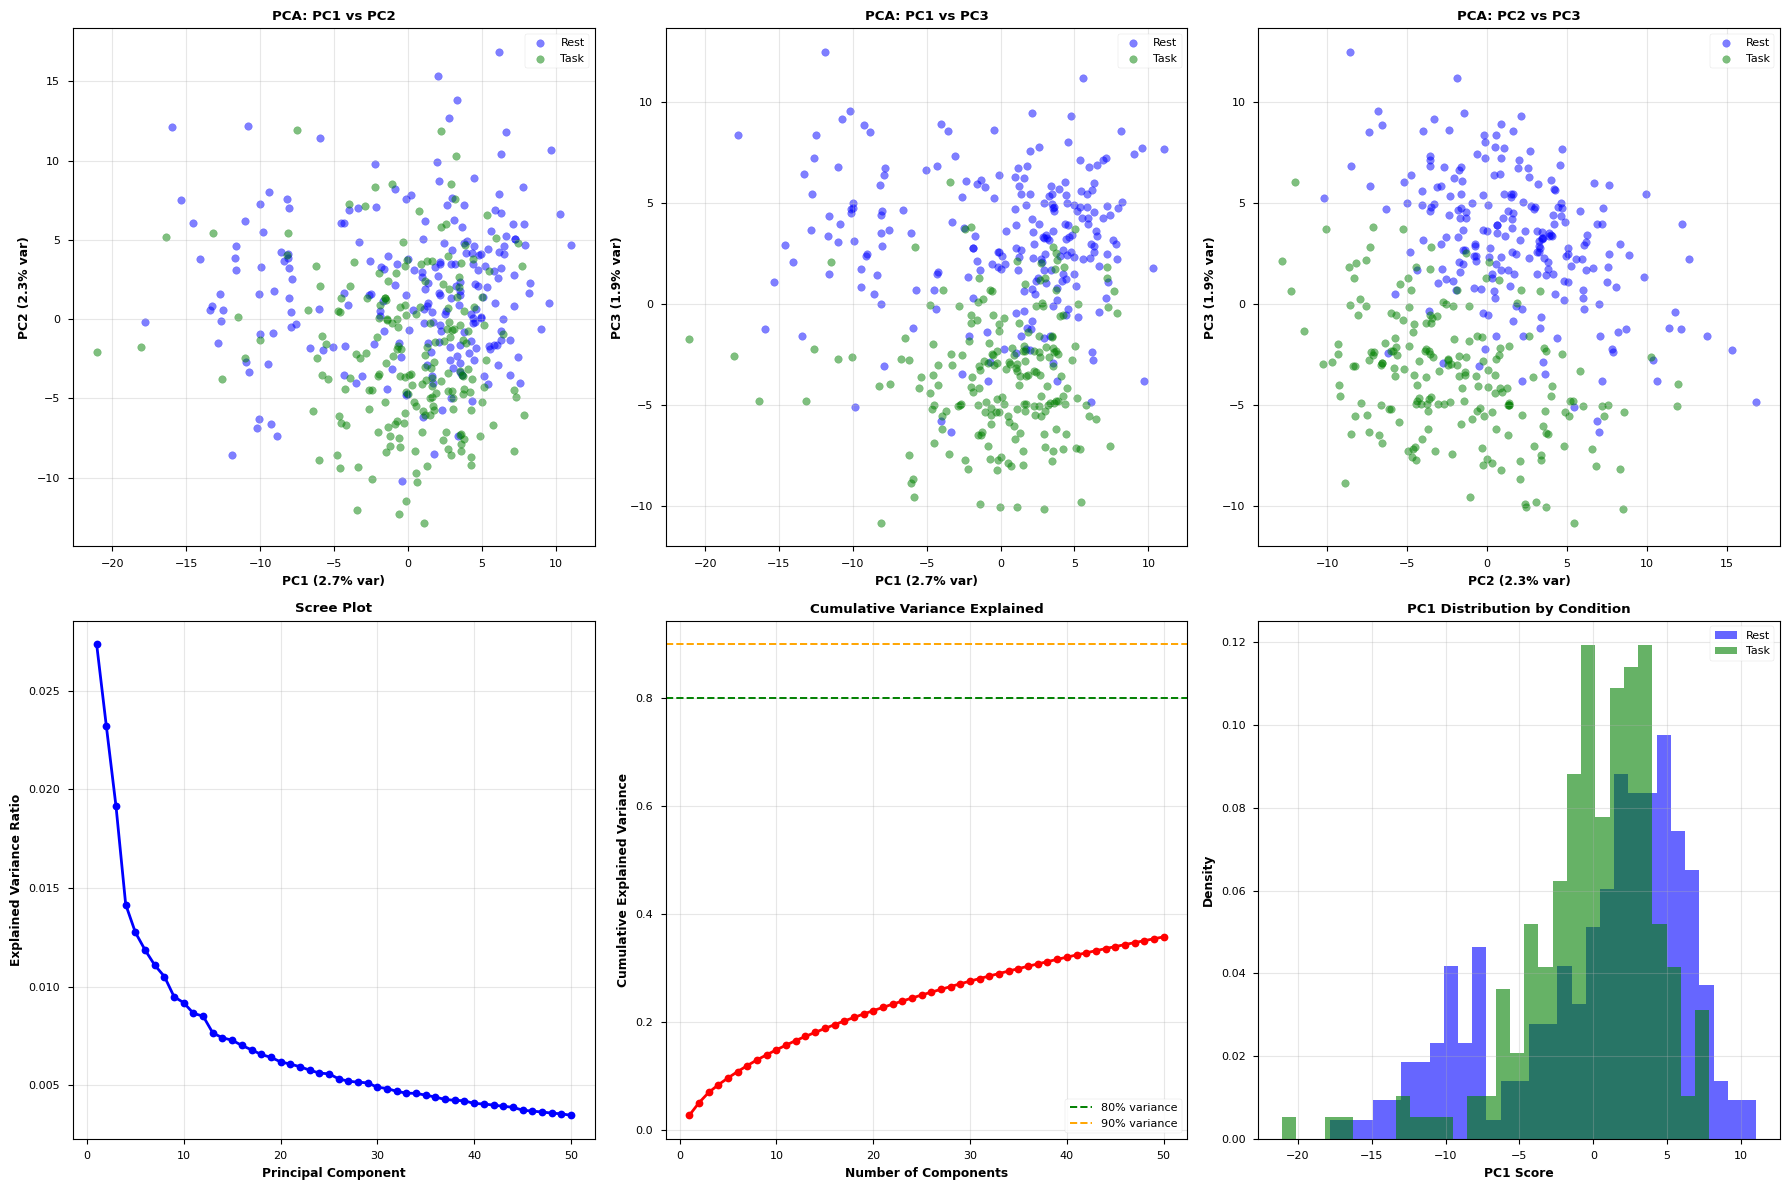

In [7]:
# PCA Visualization
print("\n5.3 Performing PCA for dimensionality reduction...")

# Combine datasets for PCA
X_combined = np.vstack([X_rest, X_task])
labels = np.array(['Rest']*len(X_rest) + ['Task']*len(X_task))

# Perform PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_combined)

print(f"  Explained variance by first 10 PCs: {pca.explained_variance_ratio_[:10].sum():.2%}")
print(f"  Explained variance by first 50 PCs: {pca.explained_variance_ratio_.sum():.2%}")

# Split back
X_rest_pca = X_pca[:len(X_rest)]
X_task_pca = X_pca[len(X_rest):]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# PC1 vs PC2
axes[0, 0].scatter(X_rest_pca[:, 0], X_rest_pca[:, 1], alpha=0.5, s=30, 
                   label='Rest', color='blue')
axes[0, 0].scatter(X_task_pca[:, 0], X_task_pca[:, 1], alpha=0.5, s=30, 
                   label='Task', color='green')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontweight='bold')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontweight='bold')
axes[0, 0].set_title('PCA: PC1 vs PC2', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# PC1 vs PC3
axes[0, 1].scatter(X_rest_pca[:, 0], X_rest_pca[:, 2], alpha=0.5, s=30, 
                   label='Rest', color='blue')
axes[0, 1].scatter(X_task_pca[:, 0], X_task_pca[:, 2], alpha=0.5, s=30, 
                   label='Task', color='green')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontweight='bold')
axes[0, 1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} var)', fontweight='bold')
axes[0, 1].set_title('PCA: PC1 vs PC3', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# PC2 vs PC3
axes[0, 2].scatter(X_rest_pca[:, 1], X_rest_pca[:, 2], alpha=0.5, s=30, 
                   label='Rest', color='blue')
axes[0, 2].scatter(X_task_pca[:, 1], X_task_pca[:, 2], alpha=0.5, s=30, 
                   label='Task', color='green')
axes[0, 2].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontweight='bold')
axes[0, 2].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} var)', fontweight='bold')
axes[0, 2].set_title('PCA: PC2 vs PC3', fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Scree plot
axes[1, 0].plot(range(1, 51), pca.explained_variance_ratio_, 'bo-', linewidth=2)
axes[1, 0].set_xlabel('Principal Component', fontweight='bold')
axes[1, 0].set_ylabel('Explained Variance Ratio', fontweight='bold')
axes[1, 0].set_title('Scree Plot', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Cumulative variance
axes[1, 1].plot(range(1, 51), np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2)
axes[1, 1].axhline(0.8, color='green', linestyle='--', label='80% variance')
axes[1, 1].axhline(0.9, color='orange', linestyle='--', label='90% variance')
axes[1, 1].set_xlabel('Number of Components', fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Explained Variance', fontweight='bold')
axes[1, 1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# PC1 distribution by condition
axes[1, 2].hist(X_rest_pca[:, 0], bins=30, alpha=0.6, color='blue', label='Rest', density=True)
axes[1, 2].hist(X_task_pca[:, 0], bins=30, alpha=0.6, color='green', label='Task', density=True)
axes[1, 2].set_xlabel('PC1 Score', fontweight='bold')
axes[1, 2].set_ylabel('Density', fontweight='bold')
axes[1, 2].set_title('PC1 Distribution by Condition', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


5.4 Performing t-SNE for non-linear dimensionality reduction...


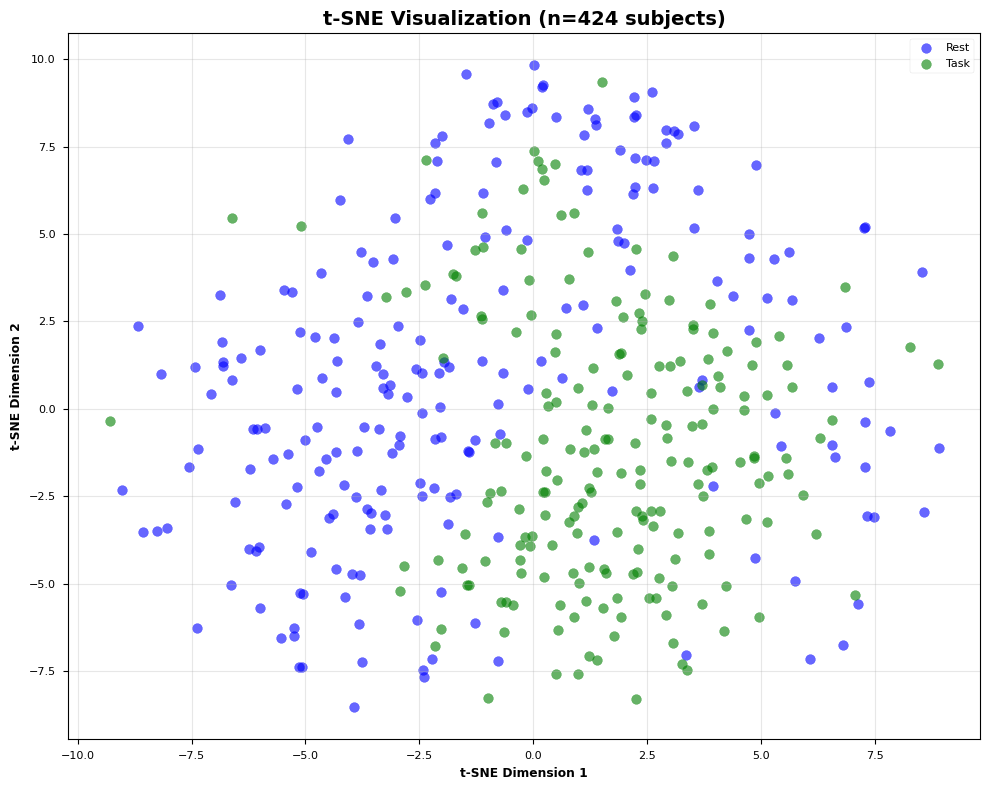

In [8]:
# t-SNE Visualization 
print("\n5.4 Performing t-SNE for non-linear dimensionality reduction...")

# Use subset for faster computation if dataset is large
n_samples_tsne = min(500, len(X_combined))
indices = np.random.choice(len(X_combined), n_samples_tsne, replace=False)
X_subset = X_combined[indices]
labels_subset = labels[indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_subset)

# Split back
rest_mask = labels_subset == 'Rest'
task_mask = labels_subset == 'Task'

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.scatter(X_tsne[rest_mask, 0], X_tsne[rest_mask, 1], 
          alpha=0.6, s=50, label='Rest', color='blue')
ax.scatter(X_tsne[task_mask, 0], X_tsne[task_mask, 1], 
          alpha=0.6, s=50, label='Task', color='green')
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold')
ax.set_title(f't-SNE Visualization (n={n_samples_tsne} subjects)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Grand Connectivity Matrices
print("SECTION 6: CORRELATION STRUCTURE")

# Extract regions from connection columns
def extract_regions_from_connections(connection_cols):
    """Extract unique region names from connection columns."""
    regions = set()
    for conn in connection_cols:
        parts = conn.split('~')
        if len(parts) == 2:
            regions.add(parts[0])
            regions.add(parts[1])
    return sorted(list(regions))

regions = extract_regions_from_connections(connection_cols)
n_regions = len(regions)
region_to_idx = {region: idx for idx, region in enumerate(regions)}

print(f"\n6.1 Extracted {n_regions} unique brain regions")
print(f"  Sample regions: {regions[:5]}")

def reconstruct_matrix(subject_values, connection_cols, region_to_idx, n_regions):
    """Reconstruct symmetric connectivity matrix from flattened connections."""
    matrix = np.zeros((n_regions, n_regions))
    
    for col, value in zip(connection_cols, subject_values):
        parts = col.split('~')
        if len(parts) == 2:
            idx_a = region_to_idx[parts[0]]
            idx_b = region_to_idx[parts[1]]
            matrix[idx_a, idx_b] = value
            matrix[idx_b, idx_a] = value
    
    # Fill diagonal with 1.0 (self-correlation)
    np.fill_diagonal(matrix, 1.0)
    
    return matrix

print("\n6.2 Reconstructing grand connectivity matrices...")

# Compute grand matrices (average across subjects)
grand_matrix_rest = np.zeros((n_regions, n_regions))
grand_matrix_task = np.zeros((n_regions, n_regions))

for i in range(len(X_rest)):
    grand_matrix_rest += reconstruct_matrix(X_rest[i], connection_cols, region_to_idx, n_regions)
grand_matrix_rest /= len(X_rest)

for i in range(len(X_task)):
    grand_matrix_task += reconstruct_matrix(X_task[i], connection_cols, region_to_idx, n_regions)
grand_matrix_task /= len(X_task)

print("✓ Grand matrices computed")

# Compute difference matrix
diff_matrix = grand_matrix_task - grand_matrix_rest

# Matrix statistics
print(f"\n6.3 Grand Matrix Statistics:")
print(f"  Rest - Mean: {grand_matrix_rest.mean():.4f}, Std: {grand_matrix_rest.std():.4f}")
print(f"  Task - Mean: {grand_matrix_task.mean():.4f}, Std: {grand_matrix_task.std():.4f}")
print(f"  Difference - Mean: {diff_matrix.mean():.4f}, Std: {diff_matrix.std():.4f}")

SECTION 6: CORRELATION STRUCTURE

6.1 Extracted 232 unique brain regions
  Sample regions: ['LH_ContA_Cingm_1', 'LH_ContA_IPS_1', 'LH_ContA_IPS_2', 'LH_ContA_IPS_3', 'LH_ContA_PFCd_1']

6.2 Reconstructing grand connectivity matrices...


✓ Grand matrices computed

6.3 Grand Matrix Statistics:
  Rest - Mean: 0.0207, Std: 0.1821
  Task - Mean: 0.0199, Std: 0.1706
  Difference - Mean: -0.0008, Std: 0.0496


In [10]:
# Matrix Similarity Metrics
print("\n6.4 Computing Matrix Similarity Metrics...")

# Correlation between matrices
# Flatten upper triangle (excluding diagonal)
triu_indices = np.triu_indices(n_regions, k=1)
rest_triu = grand_matrix_rest[triu_indices]
task_triu = grand_matrix_task[triu_indices]

corr_coef = np.corrcoef(rest_triu, task_triu)[0, 1]
print(f"  Pearson correlation between matrices: {corr_coef:.4f}")

# Frobenius norm of difference
frobenius_norm = np.linalg.norm(diff_matrix, 'fro')
print(f"  Frobenius norm of difference: {frobenius_norm:.4f}")

# Mean absolute difference
mean_abs_diff = np.abs(diff_matrix[triu_indices]).mean()
print(f"  Mean absolute difference: {mean_abs_diff:.4f}")

# Cosine similarity
from scipy.spatial.distance import cosine
cosine_sim = 1 - cosine(rest_triu, task_triu)
print(f"  Cosine similarity: {cosine_sim:.4f}")


6.4 Computing Matrix Similarity Metrics...
  Pearson correlation between matrices: 0.9572
  Frobenius norm of difference: 11.4977
  Mean absolute difference: 0.0379
  Cosine similarity: 0.9576


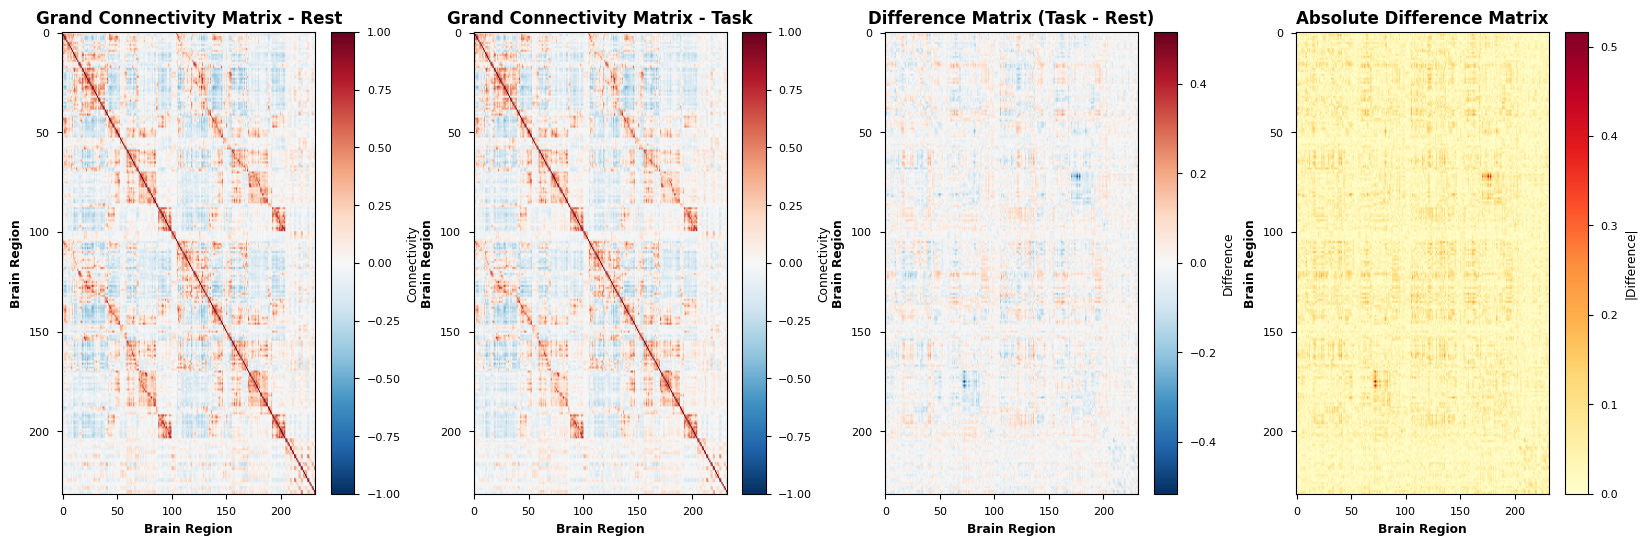

In [11]:
# Visualize Grand Matrices
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 4, wspace=0.3)

# Rest matrix
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(grand_matrix_rest, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax1.set_title('Grand Connectivity Matrix - Rest', fontweight='bold', fontsize=12)
ax1.set_xlabel('Brain Region', fontweight='bold')
ax1.set_ylabel('Brain Region', fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Connectivity')

# Task matrix
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(grand_matrix_task, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax2.set_title('Grand Connectivity Matrix - Task', fontweight='bold', fontsize=12)
ax2.set_xlabel('Brain Region', fontweight='bold')
ax2.set_ylabel('Brain Region', fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Connectivity')

# Difference matrix
ax3 = fig.add_subplot(gs[0, 2])
vmax_diff = max(abs(diff_matrix.min()), abs(diff_matrix.max()))
im3 = ax3.imshow(diff_matrix, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff, aspect='auto')
ax3.set_title('Difference Matrix (Task - Rest)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Brain Region', fontweight='bold')
ax3.set_ylabel('Brain Region', fontweight='bold')
plt.colorbar(im3, ax=ax3, label='Difference')

# Absolute difference matrix
ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(np.abs(diff_matrix), cmap='YlOrRd', vmin=0, vmax=vmax_diff, aspect='auto')
ax4.set_title('Absolute Difference Matrix', fontweight='bold', fontsize=12)
ax4.set_xlabel('Brain Region', fontweight='bold')
ax4.set_ylabel('Brain Region', fontweight='bold')
plt.colorbar(im4, ax=ax4, label='|Difference|')
plt.show()
